In [47]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import json, os, pyperclip
import joblib
from itertools import product
from scipy.signal import butter, filtfilt

import matplotlib.ticker as mticker
import pandas as pd
import control as ctl
from tqdm import tqdm

In [48]:
OPTIONS = json.loads(open('info.json', 'r').read())
OPTIONS

{'dt': 0.045,
 'offset': 3,
 'view_range': [0.7, 0.8],
 'sensor_range': [400, 900],
 'actuator_range': [0, 255],
 'sensor_filter': {'num': [0.4589418031905226, 0.4589418031905226],
  'den': [1.0, -0.08211639361895486]},
 'Fc': 6.0,
 'ts': 0.324}

In [49]:
df   = pd.read_csv('../Dataset/data_cleaned.csv')
K_CV = 5
TEMPORAL = True

x_min, x_max = OPTIONS.get('sensor_range')
u_min, u_max = OPTIONS.get('actuator_range')
dt = OPTIONS.get('dt')
ts = OPTIONS.get('ts')
OFFSET = OPTIONS.get('offset')
Fc     = OPTIONS.get('Fc')
df

,time,input,sensor
0,0.000,255,462.613338
1,0.045,255,821.401797
2,0.090,255,615.427066
3,0.135,255,494.333375
4,0.180,255,454.099439
...,...,...,...
2172,97.740,122,479.615635
2173,97.785,122,493.736691
2174,97.830,122,475.620706
2175,97.875,122,463.577425


Text(0, 0.5, 'sensor')

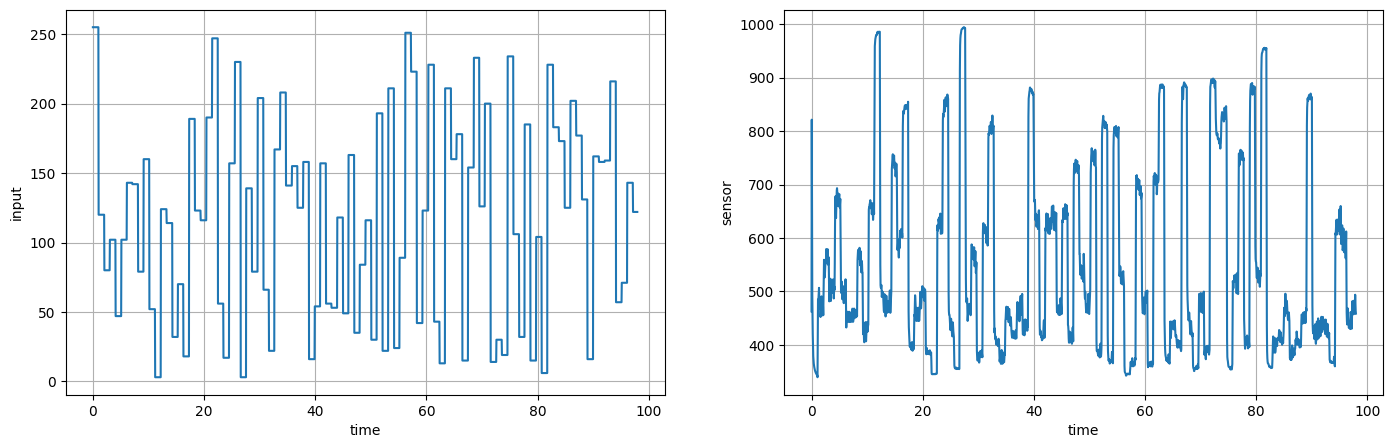

In [50]:
plt.figure(figsize=(17, 5))
plt.subplot(1, 2, 1)
plt.plot(df.time, df.input)
plt.grid()
plt.xlabel('time'); plt.ylabel('input')

plt.subplot(1, 2, 2)
plt.plot(df.time, df.sensor)
plt.grid()
plt.xlabel('time'); plt.ylabel('sensor')

In [51]:
df['delta_u'] = df.input.diff()
df['error']   = df.sensor.shift(-OFFSET) - df.sensor
df = df.dropna()
df

,time,input,sensor,delta_u,error
1,0.045,255,821.401797,0.0,-367.302358
2,0.090,255,615.427066,0.0,-195.839536
3,0.135,255,494.333375,0.0,-99.609045
4,0.180,255,454.099439,0.0,-75.643981
5,0.225,255,419.587530,0.0,-48.893199
...,...,...,...,...,...
2169,97.605,122,472.870887,0.0,6.744748
2170,97.650,122,464.728445,0.0,29.008246
2171,97.695,122,458.552516,0.0,17.068190
2172,97.740,122,479.615635,0.0,-16.038210


In [52]:
def getStates(df, key, var='y', n=10, last=True):
    table = df.copy() 
    table[f'{var}'] = table[key]

    for i in range(1, n):
        table[f'{var}(n-{i})'] = table[key].shift(i)

    table.fillna(0, inplace=True)
    columns = [f'{var}'] + [f'{var}(n-{i})' for i in range(1, n)]

    if not last:
        columns = columns[1:]

    return table[columns]


N_STATES = 3
xData = pd.concat([
    getStates(df, 'input',  var='u', n=N_STATES, last=True),  
    getStates(df, 'sensor', var='x', n=N_STATES, last=False)
], axis=1)

xData = xData.iloc[N_STATES:].reset_index(drop=True)
yData = df.sensor.values[N_STATES:]
xData

,u,u(n-1),u(n-2),x(n-1),x(n-2)
0,255,255.0,255.0,494.333375,615.427066
1,255,255.0,255.0,454.099439,494.333375
2,255,255.0,255.0,419.587530,454.099439
3,255,255.0,255.0,394.724330,419.587530
4,255,255.0,255.0,378.455458,394.724330
...,...,...,...,...,...
2165,122,122.0,122.0,482.605522,472.607198
2166,122,122.0,122.0,472.870887,482.605522
2167,122,122.0,122.0,464.728445,472.870887
2168,122,122.0,122.0,458.552516,464.728445


# MODELO

In [53]:
L   = OFFSET * dt  # Atraso de transporte (Tempo Morto)
tau = ts / 4.0     # Constante de tempo (aproximada via tempo de acomodação ts)

delta_sensor = df.sensor.max() - df.sensor.min()
delta_input  = df.input.max() - df.input.min()
K = -(delta_sensor / delta_input)

# 3. Chutes Iniciais de Ziegler-Nichols (PID)
Kp = (1.2 * tau) / (K * L)
Ki = Kp / (2.0 * L)
Kd = Kp * 0.5 * L

Kp, Ki, Kd

(-0.27694235317470056, -1.0257124191655576, -0.01869360883929229)

In [54]:
Fc = Fc * 10
K_FILTER = 1 / (2 * np.pi * Fc)

s = ctl.TransferFunction.s
C = Kp + Ki/s + (Kd*s)/(K_FILTER*s + 1)
C

TransferFunction(array([-0.01942822, -0.27966314, -1.02571242]), array([0.00265258, 1.        , 0.        ]))

polos:  (-376.991+0j) 0j
zeros:  (-7.197+0.997j) (-7.197-0.997j)


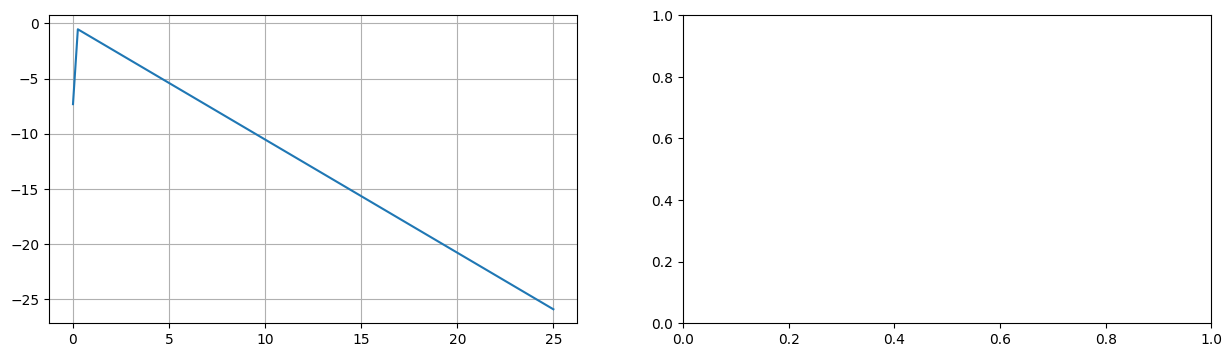

In [55]:
poles = ctl.poles(C)
zeros = ctl.zeros(C)
print('polos: ', *[np.round(pole, 3) for pole in poles])
print('zeros: ', *[np.round(zero, 3) for zero in zeros])

time, response = ctl.step_response(C)
plt.figure(figsize=(15, 4))

plt.subplot(1, 2, 1)
plt.plot(time, response)
plt.grid()

plt.subplot(1, 2, 2)
plt.show()

In [56]:
C_z = ctl.c2d(C, dt, method='tustin')
C_z

TransferFunction(array([-1.04322922,  1.5035398 , -0.54288929]), array([ 1.        , -0.21091929, -0.78908071]), 0.045)

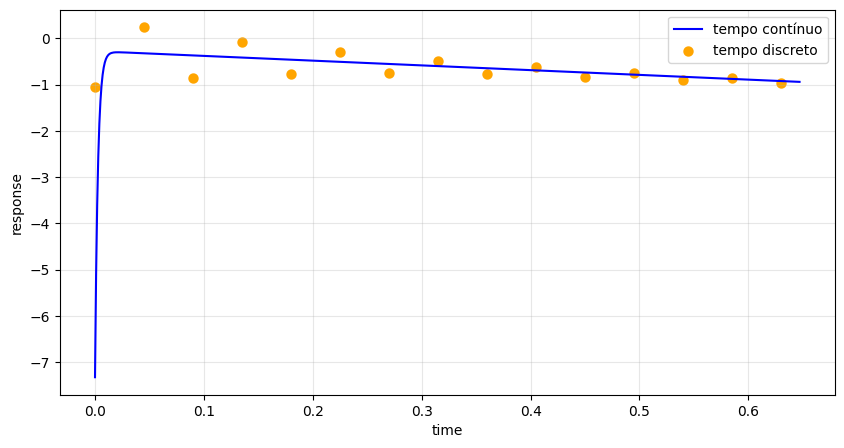

In [57]:
plt.figure(figsize=(10, 5))
time, continuous = ctl.step_response(C,   T=np.arange(0, 2*ts, 1e-3))
plt.plot(time, continuous, color='blue', label='tempo contínuo')

time, digital = ctl.step_response(C_z, T=np.arange(0, 2*ts, dt))
plt.scatter(time, digital, color='orange', linewidth=3, label='tempo discreto', s=20)
plt.xlabel('time'); plt.ylabel('response'); plt.legend(); plt.grid(alpha=.3)
plt.show()

# DIGITALIZANDO O SISTEMA
- Preparando as funções que permitem digitalizar a função de transferência em transformada $Z$
    - **printDigital**: Passando os vetores dos coeficientes do numerador e denominador para uma string que é a própria função do sistema discretizada
    - **compute**: aplica a função digitalizada a partir dos estados anteriores

- Estados anteriores
    - Y[0], Y[1], Y[2] ... se referem aos estados $Y_n$ (saída atual), $Y_{n-1}$ (penúltima saída), $Y_{n-2}$ (antipenúltima saída)

In [58]:
def getFraction(G_z):
    num, den = ctl.tfdata(G_z)
    num = np.squeeze(num)
    den = np.squeeze(den)

    num = num/den[0]
    den = den/den[0]

    if type(num) == np.float64:
        num = np.array([num])

    num = [float(val) for val in num]
    den = [float(val) for val in den]
    return (num, den) 


num, den = getFraction(C_z)
print(f'num={num} ({len(num)} states)')
print(f'num={num} ({len(num)} states)')

num=[-1.0432292161781005, 1.5035397992471802, -0.5428892867993207] (3 states)
num=[-1.0432292161781005, 1.5035397992471802, -0.5428892867993207] (3 states)


In [59]:
class Controller:
    def __init__(self, num, den):
        self.clip_on = True
        self.num = num
        self.den = den
        self.xn = np.zeros(len(num))
        self.yn = np.zeros(len(den))

    def update(self, error):
        for i in range(len(self.xn) - 1, 0, -1):
            self.xn[i] = self.xn[i-1]
        
        for i in range(len(self.yn) - 1, 0, -1):
            self.yn[i] = self.yn[i-1]
        
        self.xn[0] = error
        out = 0.0
        
        for i in range(len(self.num)):
            out += self.xn[i] * self.num[i]
            
        for i in range(1, len(self.den)):
            out -= self.yn[i] * self.den[i]
        
        if self.clip_on:
            out = np.clip(out, u_min, u_max)

        self.yn[0] = out
        return out

    def print(self):
        out = ''
        for i in range(0, len(self.num)): 
            out += f'Xn{i}*({self.num[i]:.6f}) + '

        for i in range(1, len(self.den)): 
            out += f'Yn{i}*({-1*self.den[i]:.6f}) + '
        
        print(out.replace('Xn0', 'Xn')[:-3] + ';')

    def reset(self):
        init_x = (x_max + x_min) / 2.0
        init_u = (u_max + u_min) / 2.0

        self.xn = 0.0 * np.ones_like(self.num)
        self.yn = init_u * np.ones_like(self.den)


controller = Controller(num, den)
controller.print()

Xn*(-1.043229) + Xn1*(1.503540) + Xn2*(-0.542889) + Yn1*(0.210919) + Yn2*(0.789081);


# PLANTA DO SISTEMA

In [60]:
def loadBackup(base):
    df = []

    for path in os.listdir(base):
        index = int(path.split('_')[-1])
        
        with open(f'{base}/{path}/info.json', 'r', encoding='utf-8') as file:
            data = json.loads(file.read())
        
        name = data['model']
        data = data['info']
        data['name'] = name
        data['id'] = index
        df.append(data)

    return pd.DataFrame(df).sort_values(by='id', ascending=False)


def loadModel(base, id):
    with open(f'{base}/model_{id}/info.json', 'r', encoding='utf-8') as file:
        data = json.loads(file.read())

    data['model'] = joblib.load(f'{base}/model_{id}/model.pkl')
    return data

df = loadBackup('Backup/System')
df

,r2,r2_adj,rmse,mae,name,id
0,0.989197,0.988727,17.553459,9.363199,linear_regression,1


In [61]:
id   = df.iloc[0].id
data = loadModel('Backup/System', id)

sys_variables = data['variables']
N_STATES_SYS  = sum(['u(n-' in var for var in sys_variables]) + 1

print(f'Modelo {id} Carregado  ({N_STATES_SYS} estados): {sys_variables}')
sys = data.get('model')
sys

Modelo 1 Carregado  (8 estados): ['u', 'u(n-1)', 'u(n-2)', 'u(n-3)', 'u(n-4)', 'u(n-5)', 'u(n-6)', 'u(n-7)', 'x(n-1)', 'x(n-2)', 'x(n-3)', 'x(n-4)', 'x(n-5)', 'x(n-6)', 'x(n-7)']


,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [62]:
class System:
    def __init__(self, model, n_states, variables):
        self.model = model
        self.n_states = n_states
        self.variables = variables
        self.reset()

    def update(self, actuator):
        self.uBuffer.insert(0, actuator)
        self.uBuffer.pop()
        
        featureVector   = self.uBuffer + self.xBuffer[:-1]
        nextSensorValue = self.model.predict(pd.DataFrame([featureVector], columns=self.variables))[0]
        
        self.xBuffer.insert(0, nextSensorValue)
        self.xBuffer.pop()
        
        return nextSensorValue

    def reset(self):
        init_x = (x_max + x_min) / 2.0
        init_u = (u_max + u_min) / 2.0
        self.xBuffer = [init_x] * self.n_states
        self.uBuffer = [init_u] * self.n_states


models = sorted(os.listdir('Backup/System'))
path   = f'Backup/System/{models[-1]}/model.pkl'

model  = joblib.load(path)
system = System(model, N_STATES_SYS, sys_variables)
model

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [63]:
class Feedback:
    def __init__(self, system, controller, dt):
        self.system = system
        self.controller = controller
        self.dt = dt
        self.reset()

    def predict(self, sensor, setpoint):
        error = (setpoint - sensor)
        u = self.controller.update(error)
        x = self.system.update(u)
        return (x, u)
    
    def simulate(self, setpoints):
        xData = np.zeros_like(setpoints)
        uData = np.zeros_like(setpoints)
        Xn = setpoints[0]

        for i, setpoint in enumerate(setpoints):
            Xn, Un = self.predict(Xn, setpoint)
            xData[i] = Xn
            uData[i] = Un
        
        return (xData, uData)
    
    def reset(self):
        self.system.reset()
        self.controller.reset()
        
    
feedback = Feedback(system, controller, dt)

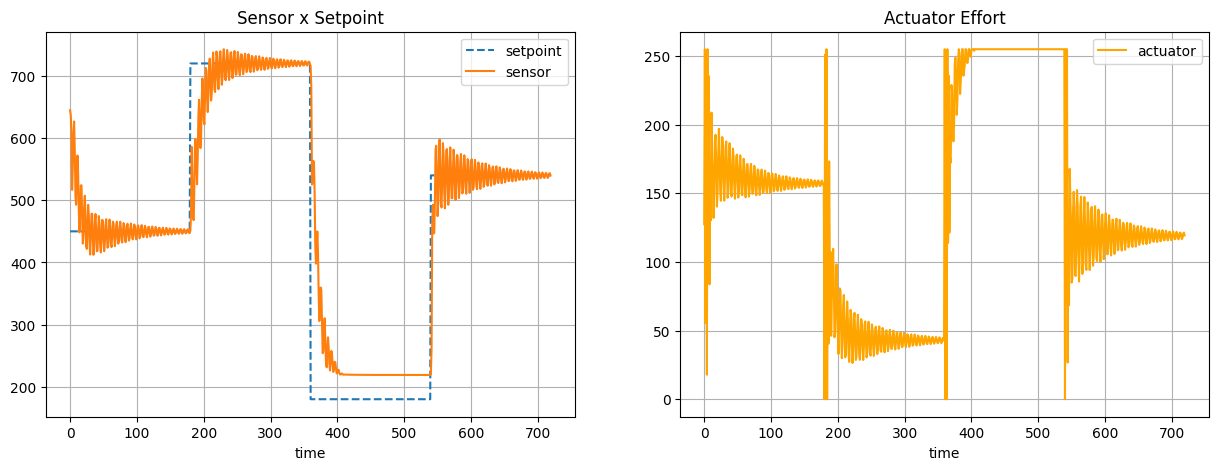

In [64]:
def makeSteps(stepList, totalLength):
    lastStep = stepList[-1]
    stepSize = totalLength // len(stepList)
    stepArray = []

    for stepVal in stepList:
        stepArray = stepArray + list(stepVal * np.ones(stepSize))

    sizeLeft = totalLength - len(stepArray)

    if sizeLeft > 0:
        stepArray = stepArray + list(lastStep * np.ones(sizeLeft))

    return np.array(stepArray[:totalLength])


STEP      = int(25*ts/dt)
setpoints = [x_max*0.5]*STEP + [x_max*0.8]*STEP + [x_max*0.2]*STEP + [x_max*0.6]*STEP

sensor, actuator  = feedback.simulate(setpoints)
error = np.mean(np.abs(setpoints - sensor))

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(setpoints, label='setpoint', linestyle='--')
plt.plot(sensor, label='sensor')
plt.title('Sensor x Setpoint')
plt.xlabel('time')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(actuator, color='orange', label='actuator')
plt.title('Actuator Effort')
plt.xlabel('time')
plt.legend()
plt.grid()
plt.show()

In [65]:
error

np.float64(32.81800758322184)

# CHUTANDO

In [66]:
Kp_range = (-Kp*1000, +Kp*1000)
Ki_range = (-Ki*1000, +Ki*1000)
Kd_range = (-Kd*1000, +Kd*1000)

print(Kp_range)
print(Ki_range)
print(Kd_range)

(276.94235317470054, -276.94235317470054)
(1025.7124191655575, -1025.7124191655575)
(18.69360883929229, -18.69360883929229)


In [70]:
def getKick(Kp, Ki, Kd):
    s = ctl.TransferFunction.s
    C = Kp + Ki/s + (Kd*s)/(K_FILTER*s + 1)

    C_z = ctl.c2d(C, dt, method='tustin')
    num, den   = getFraction(C_z)
    controller = Controller(num, den)
    feedback = Feedback(system, controller, dt)
    
    sensor, actuator  = feedback.simulate(setpoints)
    error = np.mean(np.abs(setpoints - sensor))
    return error


df = []
for i in tqdm(range(100)):
    Kp_kick = np.random.uniform(*Kp_range)
    Ki_kick = np.random.uniform(*Ki_range)
    Kd_kick = np.random.uniform(*Kd_range)
    error = getKick(Kp_kick, Ki_kick, Kd_kick)
    df.append({'Kp': Kp_kick, 'Ki': Ki_kick, 'Kd': Kd_kick, 'error': error})
    

df = pd.DataFrame(df).sort_values(by='error', ascending=True)
df

100%|██████████| 100/100 [00:38<00:00,  2.63it/s]


,Kp,Ki,Kd,error
68,247.720707,-705.746166,5.026154,149.194676
21,15.192296,-454.009488,-4.085801,152.092329
35,265.053494,-412.079668,-7.491857,154.481960
19,22.528944,-704.487218,13.142837,156.842983
76,71.120272,-638.497014,17.640980,156.842983
...,...,...,...,...
71,219.912937,-105.484481,16.150630,259.928278
42,-81.834792,549.001179,-0.239046,336.896390
40,267.984745,393.150196,-6.301407,363.167358
24,189.716117,482.156053,-2.434107,400.592547


181.4576717609326 535.9914911342876 -0.5573753574069968 406.87049230573353


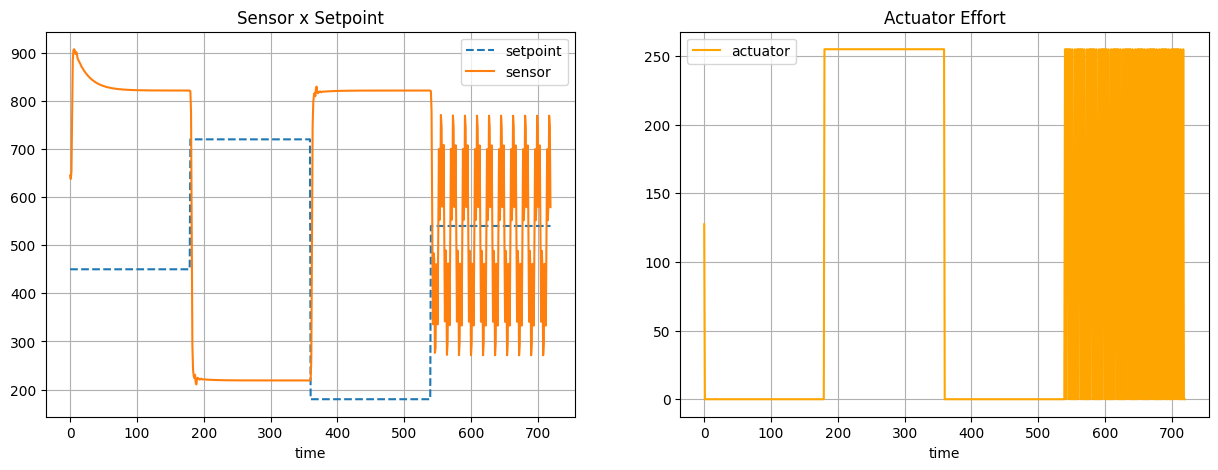

In [68]:
Kp, Ki, Kd, error = df.iloc[0].tolist()
print(Kp, Ki, Kd, error)

s = ctl.TransferFunction.s
C = Kp + Ki/s + (Kd*s)/(K_FILTER*s + 1)

C_z = ctl.c2d(C, dt, method='tustin')
num, den   = getFraction(C_z)
controller = Controller(num, den)
feedback = Feedback(system, controller, dt)

sensor, actuator  = feedback.simulate(setpoints)
error = np.mean(np.abs(setpoints - sensor))

plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(setpoints, label='setpoint', linestyle='--')
plt.plot(sensor, label='sensor')
plt.title('Sensor x Setpoint')
plt.xlabel('time')
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(actuator, color='orange', label='actuator')
plt.title('Actuator Effort')
plt.xlabel('time')
plt.legend()
plt.grid()
plt.show()

In [69]:
import os
import json

os.makedirs('Backup/Controller/model_1', exist_ok=True)
with open('Backup/Controller/model_1/info.json', 'w') as f:
    json.dump({
        'num': num,
        'den': den
    }, f, indent=4)
print('Controller parameters saved to Backup/Controller/model_1/info.json')


Controller parameters saved to Backup/Controller/model_1/info.json
